<a href="https://colab.research.google.com/github/lakShay3654/Machine-Learning/blob/main/rice_yield_analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Rice Yield Analysis and Machine Learning Models

This notebook analyzes rice yield, production, and harvested area data using **Linear**, **Polynomial**, and **Multivariate Regression** models.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# 1. READ FAOSTAT DATA
df = pd.read_csv("rice.csv")

print("File loaded successfully!")
print("Original rows:", len(df))

File loaded successfully!
Original rows: 192


In [2]:
# 2. FILTER ONLY RICE
rice = df[df["Item"] == "Rice"].copy()
print("Rice rows:", len(rice))

Rice rows: 192


In [3]:
# 3. SEPARATE YIELD, PRODUCTION AND AREA
yield_data = rice[rice["Element"] == "Yield"][["Year", "Value"]].rename(columns={"Value": "Yield"})
production_data = rice[rice["Element"] == "Production"][["Year", "Value"]].rename(columns={"Value": "Production"})
area_data = rice[rice["Element"] == "Area harvested"][["Year", "Value"]].rename(columns={"Value": "Area"})

# 4. COMBINE AND CLEAN DATA
data = yield_data.merge(production_data, on="Year").merge(area_data, on="Year")
data = data.dropna().sort_values("Year")

print("Final dataset preview:")
print(data.head())

Final dataset preview:
   Year   Yield  Production        Area
0  1961  1541.9  53494496.0  34694000.0
1  1962  1395.9  49825552.0  35695008.0
2  1963  1549.8  55497008.0  35809008.0
3  1964  1617.1  58962000.0  36462000.0
4  1965  1293.6  45883504.0  35470000.0


LINEAR REGRESSION RESULTS:
MSE : 24565.013968623574
RMSE: 156.7323003360302
MAE : 119.34941439442761
R2  : 0.9723664319558363


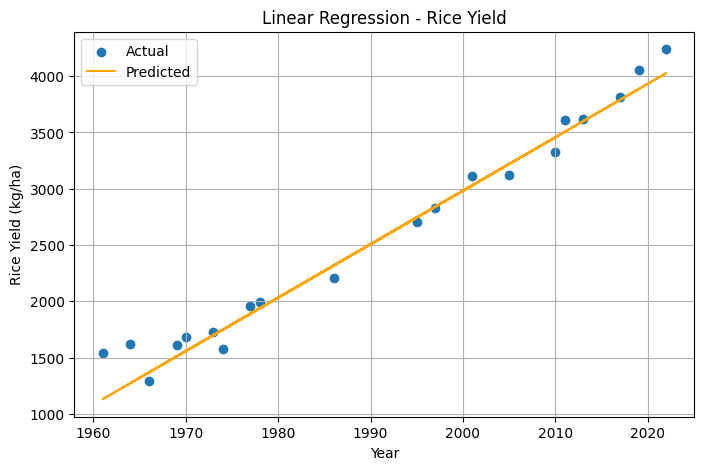

In [4]:
# 5. LINEAR REGRESSION
X = data[["Year"]]
y = data["Yield"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.30, random_state=42)

linear_model = LinearRegression()
linear_model.fit(X_train, y_train)

y_pred_linear = linear_model.predict(X_test)

mse_linear = mean_squared_error(y_test, y_pred_linear)
rmse_linear = np.sqrt(mse_linear)
mae_linear = mean_absolute_error(y_test, y_pred_linear)
r2_linear = r2_score(y_test, y_pred_linear)

print("LINEAR REGRESSION RESULTS:")
print("MSE :", mse_linear)
print("RMSE:", rmse_linear)
print("MAE :", mae_linear)
print("R2  :", r2_linear)

plt.figure(figsize=(8, 5))
plt.scatter(X_test["Year"], y_test, label="Actual")
plt.plot(X_test["Year"], y_pred_linear, label="Predicted", color="orange")
plt.xlabel("Year")
plt.ylabel("Rice Yield (kg/ha)")
plt.title("Linear Regression - Rice Yield")
plt.legend()
plt.grid()
plt.show()

POLYNOMIAL REGRESSION RESULTS:
MSE : 12308.604098089792
RMSE: 110.94414855272807
MAE : 90.63169799544386
R2  : 0.9861538589268593


/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but PolynomialFeatures was fitted with feature names
  warnings.warn(


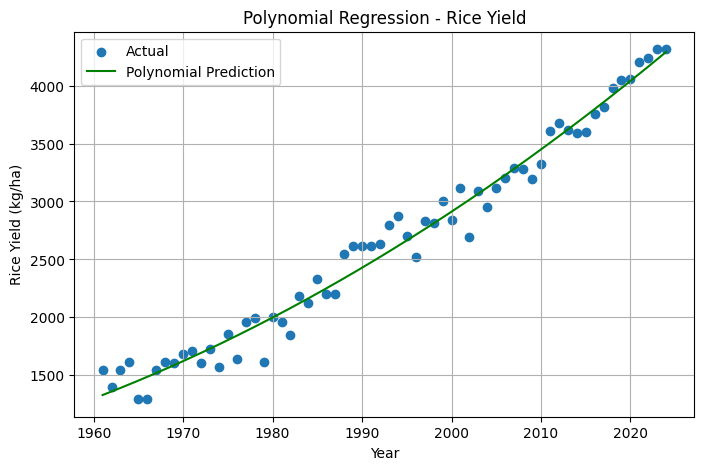

In [5]:
# 6. POLYNOMIAL REGRESSION
poly = PolynomialFeatures(degree=2)
X_poly = poly.fit_transform(X)

X_train_poly, X_test_poly, y_train_poly, y_test_poly = train_test_split(X_poly, y, test_size=0.30, random_state=42)

poly_model = LinearRegression()
poly_model.fit(X_train_poly, y_train_poly)

y_pred_poly = poly_model.predict(X_test_poly)

mse_poly = mean_squared_error(y_test_poly, y_pred_poly)
rmse_poly = np.sqrt(mse_poly)
mae_poly = mean_absolute_error(y_test_poly, y_pred_poly)
r2_poly = r2_score(y_test_poly, y_pred_poly)

print("POLYNOMIAL REGRESSION RESULTS:")
print("MSE :", mse_poly)
print("RMSE:", rmse_poly)
print("MAE :", mae_poly)
print("R2  :", r2_poly)

years = np.linspace(data["Year"].min(), data["Year"].max(), 200).reshape(-1, 1)
years_poly = poly.transform(years)
predicted_yield = poly_model.predict(years_poly)

plt.figure(figsize=(8, 5))
plt.scatter(data["Year"], data["Yield"], label="Actual")
plt.plot(years, predicted_yield, label="Polynomial Prediction", color="green")
plt.xlabel("Year")
plt.ylabel("Rice Yield (kg/ha)")
plt.title("Polynomial Regression - Rice Yield")
plt.legend()
plt.grid()
plt.show()

MULTIVARIATE REGRESSION RESULTS:
MSE : 1810.4328813182062
RMSE: 42.549181911268356
MAE : 31.941589176511126
R2  : 0.9979634157636059


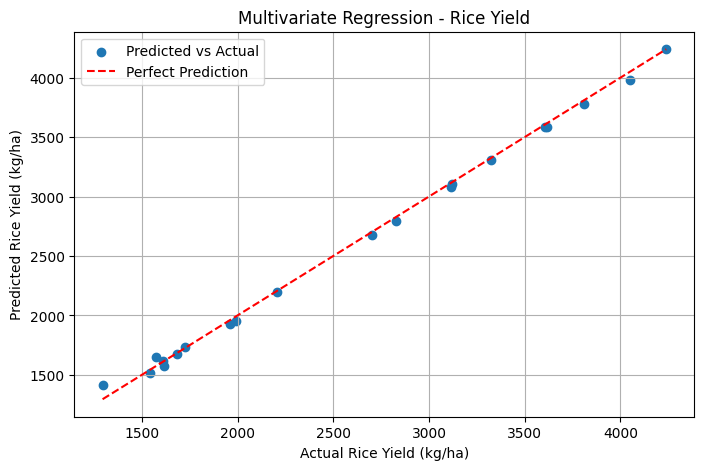

In [6]:
# 7. MULTIVARIATE REGRESSION
X_m = data[["Year", "Production", "Area"]]
X_train_multi, X_test_multi, y_train_multi, y_test_multi = train_test_split(X_m, y, test_size=0.30, random_state=42)

multi_model = LinearRegression()
multi_model.fit(X_train_multi, y_train_multi)

y_pred_multi = multi_model.predict(X_test_multi)

mse_multi = mean_squared_error(y_test_multi, y_pred_multi)
rmse_multi = np.sqrt(mse_multi)
mae_multi = mean_absolute_error(y_test_multi, y_pred_multi)
r2_multi = r2_score(y_test_multi, y_pred_multi)

print("MULTIVARIATE REGRESSION RESULTS:")
print("MSE :", mse_multi)
print("RMSE:", rmse_multi)
print("MAE :", mae_multi)
print("R2  :", r2_multi)

plt.figure(figsize=(8, 5))
plt.scatter(y_test_multi, y_pred_multi, label="Predicted vs Actual")
minimum = min(y_test_multi.min(), y_pred_multi.min())
maximum = max(y_test_multi.max(), y_pred_multi.max())
plt.plot([minimum, maximum], [minimum, maximum], label="Perfect Prediction", color="red", linestyle="--")
plt.xlabel("Actual Rice Yield (kg/ha)")
plt.ylabel("Predicted Rice Yield (kg/ha)")
plt.title("Multivariate Regression - Rice Yield")
plt.legend()
plt.grid()
plt.show()

In [7]:
# 8. MODEL COMPARISON & FUTURE PREDICTIONS
results = pd.DataFrame({
    "Model": ["Linear Regression", "Polynomial Regression", "Multivariate Regression"],
    "MSE": [mse_linear, mse_poly, mse_multi],
    "RMSE": [rmse_linear, rmse_poly, rmse_multi],
    "MAE": [mae_linear, mae_poly, mae_multi],
    "R2": [r2_linear, r2_poly, r2_multi]
})

print("\n====================================")
print("MODEL COMPARISON")
print("====================================")
print(results)

future_year = 2030
future_df = pd.DataFrame([[future_year]], columns=["Year"])
future_prediction = linear_model.predict(future_df)[0]
future_prediction_poly = poly_model.predict(poly.transform(future_df))[0]

print("\n====================================")
print("FUTURE PREDICTION (2030)")
print("====================================")
print(f"Linear predicted rice yield for {future_year}: {future_prediction:.2f} kg/ha")
print(f"Polynomial predicted rice yield for {future_year}: {future_prediction_poly:.2f} kg/ha")


MODEL COMPARISON
                     Model           MSE        RMSE         MAE        R2
0        Linear Regression  24565.013969  156.732300  119.349414  0.972366
1    Polynomial Regression  12308.604098  110.944149   90.631698  0.986154
2  Multivariate Regression   1810.432881   42.549182   31.941589  0.997963

FUTURE PREDICTION (2030)
Linear predicted rice yield for 2030: 4406.20 kg/ha
Polynomial predicted rice yield for 2030: 4683.99 kg/ha
